# Data

In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)

from data_generator import generate_dataset

In [2]:
data = generate_dataset()

### Тренировочные данные

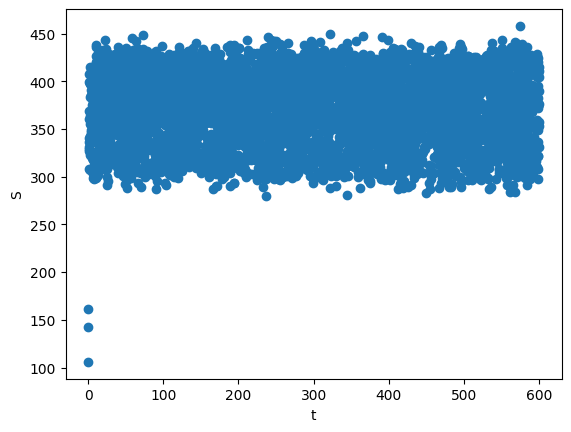

In [8]:
import matplotlib.pyplot as plt 
plt.scatter(data['t_train'], data['S_train'])
plt.xlabel('t')
plt.ylabel('S')
plt.show()

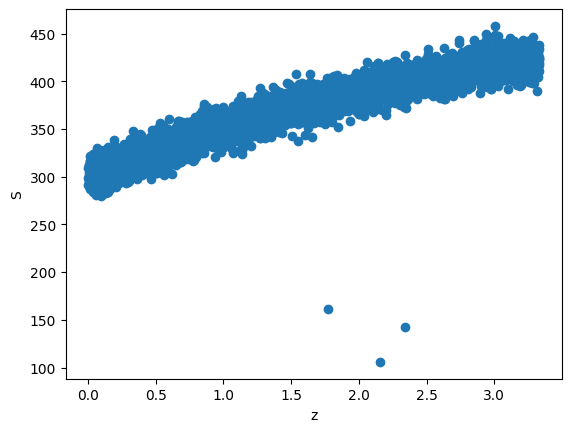

In [9]:
plt.scatter(data['z_train'], data['S_train'])
plt.xlabel('z')
plt.ylabel('S')
plt.show()

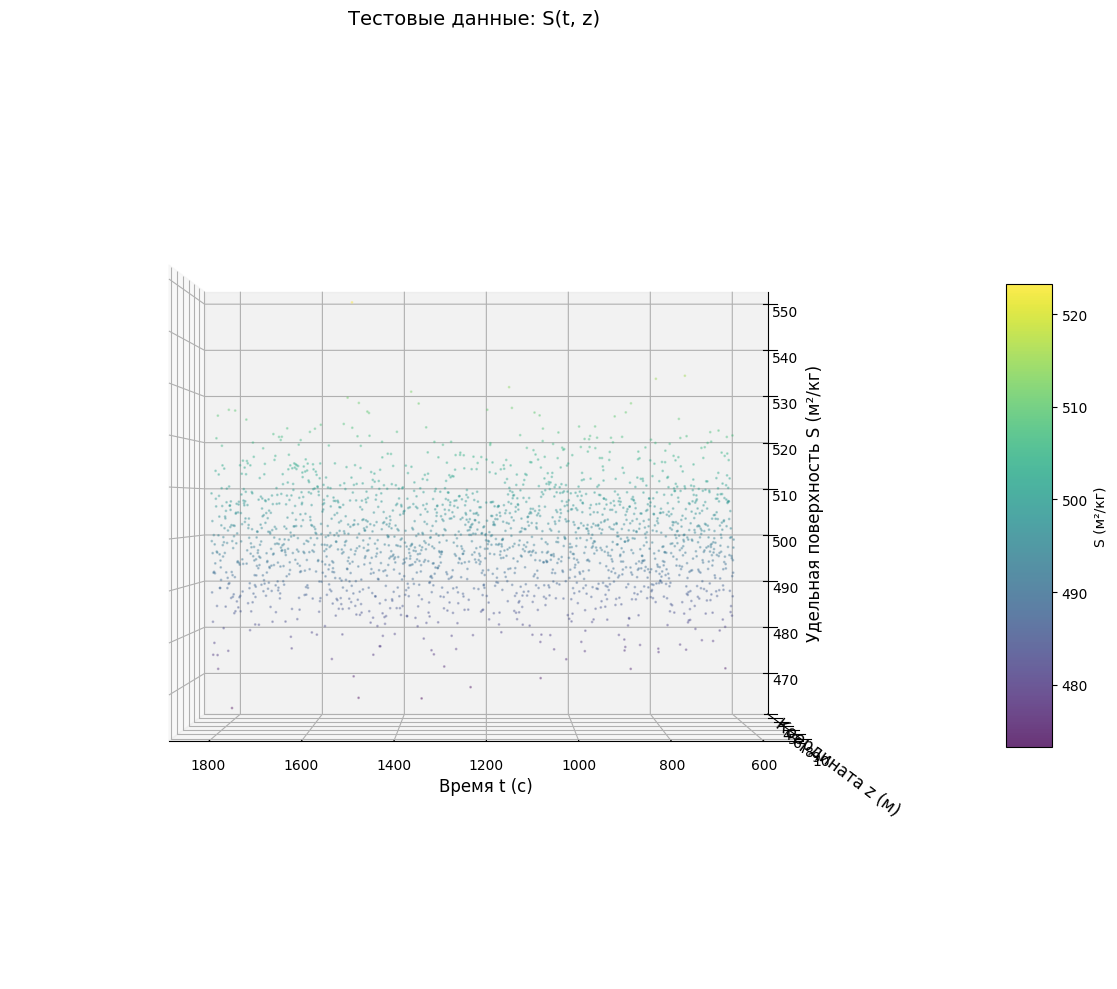

In [7]:
t_test = data['t_test'].detach().numpy().flatten()
z_test = data['z_test'].detach().numpy().flatten()
S_test = data['S_test'].detach().numpy().flatten()

# Создаем регулярную сетку для интерполяции
t_grid = np.linspace(t_test.min(), t_test.max(), 50)
z_grid = np.linspace(z_test.min(), z_test.max(), 50)
T, Z = np.meshgrid(t_grid, z_grid)

# Интерполируем данные на регулярную сетку
S_grid = griddata((t_test, z_test), S_test, (T, Z), method='cubic')

# Строим 3D поверхность
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
surf = ax.plot_surface(T, Z, S_grid, cmap='viridis', alpha=0.8, 
                        linewidth=0, antialiased=True)

# Добавляем исходные точки
ax.scatter(t_test, z_test, S_test, c=S_test, cmap='viridis', 
            s=1, alpha=0.3, label='Данные')

# Настройка осей
ax.set_xlabel('Время t (с)', fontsize=12, labelpad=10)
ax.set_ylabel('Координата z (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Удельная поверхность S (м²/кг)', fontsize=12, labelpad=10)
ax.set_title('Тестовые данные: S(t, z)', fontsize=14, pad=20)

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='S (м²/кг)')

plt.tight_layout()
ax.view_init(elev=0,  
            azim=90)
plt.show()

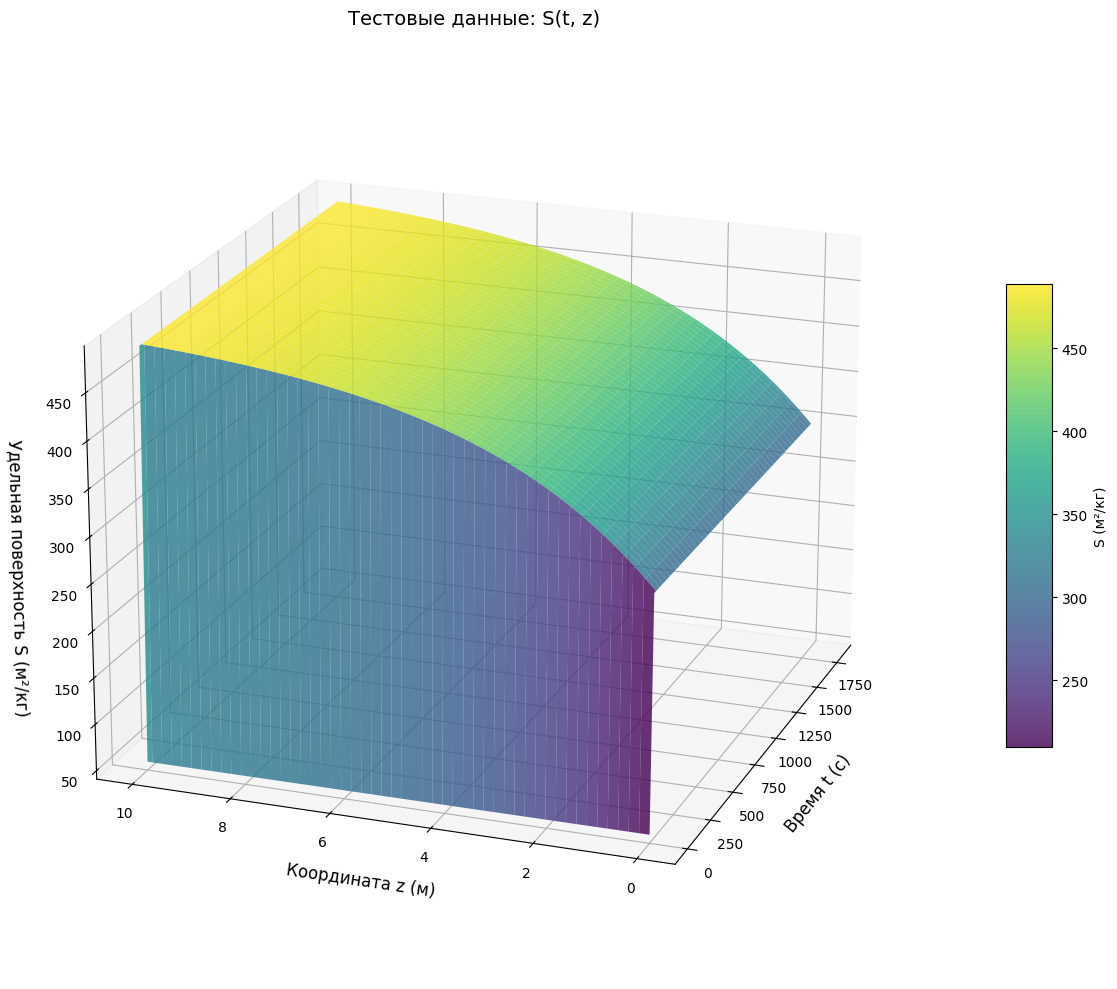

In [3]:
T, Z, S = data["T"].numpy(), data["Z"].numpy(), data["S"]

# Строим 3D поверхность
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
surf = ax.plot_surface(T, Z, S, cmap='viridis', alpha=0.8, 
                        linewidth=0, antialiased=True)

# Добавляем исходные точки
# ax.scatter(t_test, z_test, S_test, c=S_test, cmap='viridis', 
#             s=1, alpha=0.3, label='Данные')

# Настройка осей
ax.set_xlabel('Время t (с)', fontsize=12, labelpad=10)
ax.set_ylabel('Координата z (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Удельная поверхность S (м²/кг)', fontsize=12, labelpad=10)
ax.set_title('Тестовые данные: S(t, z)', fontsize=14, pad=20)

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='S (м²/кг)')

plt.tight_layout()
ax.view_init(elev=20,  # вращение в вертикальной плоскости
            azim=200) # вращение в горизантальной плоскости
plt.show()

# PINN

In [3]:
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.PINN import PINN
from loss.pinn_loss import pinn_loss

## PINN, обученная с заданными коэффициентами

k = 0.12 <br>
v_m = 0.2 <br>
epochs = 30_000

### все параметры (включая mse)

 lambda_pde=3.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [ ]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=3.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=4.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 512323.344
Epoch 100 | Loss: 480226.250
Epoch 200 | Loss: 458416.688
Epoch 300 | Loss: 438576.938
Epoch 400 | Loss: 420110.875
Epoch 500 | Loss: 402837.719
Epoch 600 | Loss: 386647.250
Epoch 700 | Loss: 370972.438
Epoch 800 | Loss: 355884.969
Epoch 900 | Loss: 341524.406
Epoch 1000 | Loss: 327854.312
Epoch 1100 | Loss: 314848.719
Epoch 1200 | Loss: 302480.750
Epoch 1300 | Loss: 290719.344
Epoch 1400 | Loss: 279542.625
Epoch 1500 | Loss: 268948.750
Epoch 1600 | Loss: 258916.969
Epoch 1700 | Loss: 249428.594
Epoch 1800 | Loss: 240464.203
Epoch 1900 | Loss: 231996.422
Epoch 2000 | Loss: 223991.766
Epoch 2100 | Loss: 216450.219
Epoch 2200 | Loss: 209361.578
Epoch 2300 | Loss: 202704.078
Epoch 2400 | Loss: 196472.969
Epoch 2500 | Loss: 190648.891
Epoch 2600 | Loss: 185222.938
Epoch 2700 | Loss: 180175.500
Epoch 2800 | Loss: 175494.031
Epoch 2900 | Loss: 171164.078
Epoch 3000 | Loss: 167161.750
Epoch 3100 | Loss: 144068.969
Epoch 3200 | Loss: 122115.383
E

In [10]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse_pde.pth'))

### без MSE

lambda_pde=2.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=0.<br>

In [11]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=2.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=0.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    S_pred = pinn(data['t_train'], data['z_train'])
    diff = data["S_train"] - S_pred

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | diff: {torch.mean(diff**2)}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 12208.944 | diff: 248000.6875
Epoch 100 | Loss: 9204.741 | diff: 233293.65625
Epoch 200 | Loss: 7780.582 | diff: 224227.796875
Epoch 300 | Loss: 6893.516 | diff: 216883.484375
Epoch 400 | Loss: 6355.116 | diff: 210951.921875
Epoch 500 | Loss: 6047.575 | diff: 206282.953125
Epoch 600 | Loss: 5884.697 | diff: 202739.078125
Epoch 700 | Loss: 5805.472 | diff: 200160.921875
Epoch 800 | Loss: 5770.278 | diff: 198370.296875
Epoch 900 | Loss: 5755.989 | diff: 197184.875
Epoch 1000 | Loss: 5750.560 | diff: 196437.0
Epoch 1100 | Loss: 5747.776 | diff: 195982.921875
Epoch 1200 | Loss: 5700.937 | diff: 194956.234375
Epoch 1300 | Loss: 5683.094 | diff: 193542.59375
Epoch 1400 | Loss: 5674.049 | diff: 192460.90625
Epoch 1500 | Loss: 5668.344 | diff: 191652.875
Epoch 1600 | Loss: 5664.445 | diff: 191055.359375
Epoch 1700 | Loss: 5661.754 | diff: 190630.359375
Epoch 1800 | Loss: 5660.145 | diff: 190351.515625
Epoch 1900 | Loss: 5659.197 | diff: 190185.34375
Epoch 2

In [12]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_pde.pth'))

### без pde

lambda_pde=0.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [15]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=0.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=2.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 502019.625
Epoch 100 | Loss: 469002.062
Epoch 200 | Loss: 448028.906
Epoch 300 | Loss: 428747.781
Epoch 400 | Loss: 410769.750
Epoch 500 | Loss: 393945.031
Epoch 600 | Loss: 378181.656
Epoch 700 | Loss: 363383.625
Epoch 800 | Loss: 348384.250
Epoch 900 | Loss: 334319.875
Epoch 1000 | Loss: 320931.375
Epoch 1100 | Loss: 308201.688
Epoch 1200 | Loss: 296105.750
Epoch 1300 | Loss: 284621.844
Epoch 1400 | Loss: 273729.156
Epoch 1500 | Loss: 263407.500
Epoch 1600 | Loss: 253637.031
Epoch 1700 | Loss: 244396.125
Epoch 1800 | Loss: 235669.828
Epoch 1900 | Loss: 227427.609
Epoch 2000 | Loss: 217934.781
Epoch 2100 | Loss: 201015.359
Epoch 2200 | Loss: 188850.938
Epoch 2300 | Loss: 177509.531
Epoch 2400 | Loss: 167230.516
Epoch 2500 | Loss: 163123.062
Epoch 2600 | Loss: 148728.234
Epoch 2700 | Loss: 139637.344
Epoch 2800 | Loss: 131213.828
Epoch 2900 | Loss: 123659.680
Epoch 3000 | Loss: 115587.242
Epoch 3100 | Loss: 151286.516
Epoch 3200 | Loss: 101744.609
E

In [16]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse.pth'))

### Визуализация 3х моделей

In [216]:
# --- MSE PDE ---
pinn_mse_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse_pde.pth"))
pinn_mse_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_mse_pde.eval()

# --- MSE ---
pinn_mse = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse.pth"))
pinn_mse.load_state_dict(checkpoint["model_state_dict"])

pinn_mse.eval()

# --- PDE ---
pinn_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_pde.pth"))
pinn_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_pde.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=1, bias=True)
  )
)

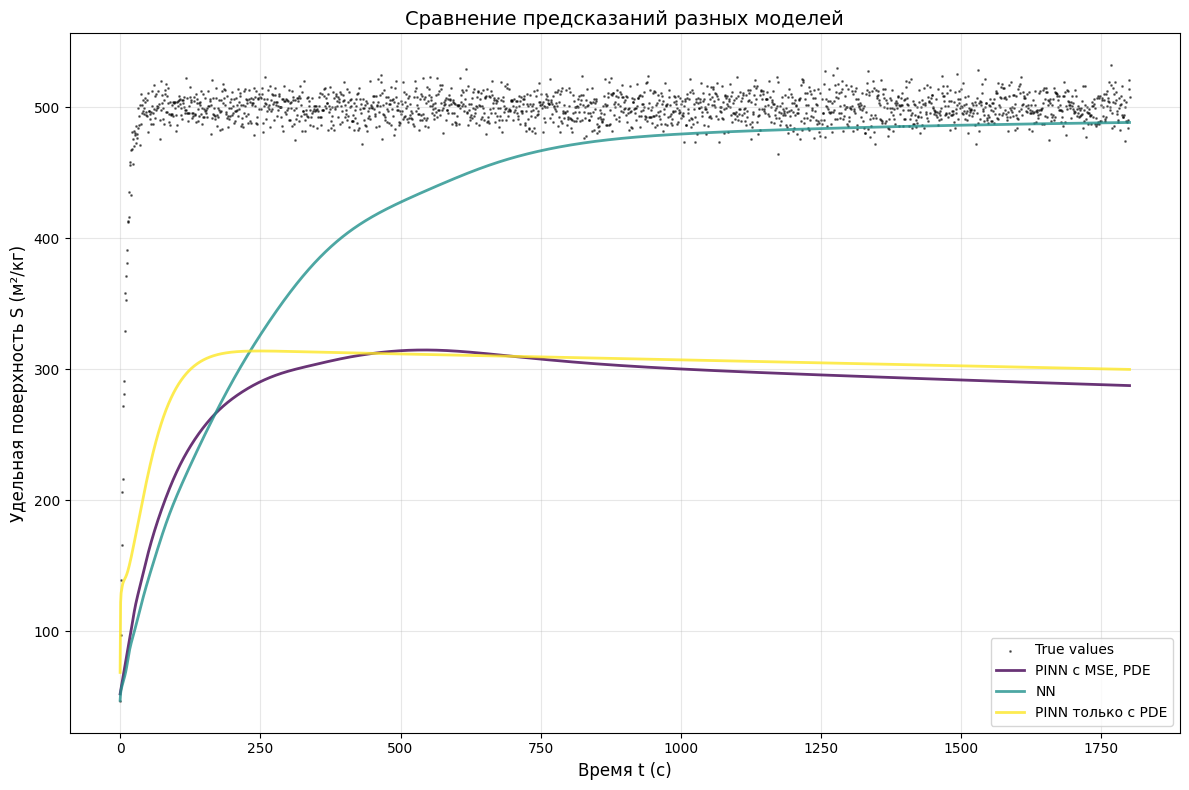

In [ ]:
# неактуальный график
plt.figure(figsize=(12, 8))
t_test = data['t_train'].detach().numpy().flatten()
z_test = data['z_train'].detach().numpy().flatten()
S_test = data['S_train'].detach().numpy().flatten()
models = [pinn_mse_pde, pinn_mse, pinn_pde]
model_names = ['PINN с MSE, PDE', 'NN', 'PINN только с PDE']

# Строим истинные значения
plt.scatter(t_test, S_test, s=1, alpha=0.5, 
               color='black', label='True values')
    
# Строим предсказания каждой модели
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

for i, (model, name) in enumerate(zip(models, model_names)):
    S_pred = model(data['t_train'], data['z_train']).detach().numpy().flatten()
    plt.plot(t_test, S_pred, linewidth=2, 
                color=colors[i], label=name, alpha=0.8)

plt.xlabel('Время t (с)', fontsize=12)
plt.ylabel('Удельная поверхность S (м²/кг)', fontsize=12)
plt.title('Сравнение предсказаний разных моделей', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D

def plot_multiple_pinns(models_dict, t_max=1800.0, z_max=10.0, v_m=0.2, k=0.12, S_max=500.0, S0=50.0):
    """
    Строит сравнительные графики для нескольких моделей.
    
    Аргументы:
        models_dict (dict): Словарь вида {'Имя модели 1': model1, 'Имя модели 2': model2}
    """
    # 1. Создаем равномерную сетку
    n_points = 100
    t_lin = np.linspace(0, t_max, n_points)
    z_lin = np.linspace(0, z_max, n_points)
    T, Z = np.meshgrid(t_lin, z_lin, indexing='ij')

    # 2. Вычисляем точное аналитическое решение
    # tau = T - Z / v_m
    # S_exact = np.where(
    #     tau > 0,
    #     S_max - (S_max - S0) * np.exp(-k * Z / v_m),
    #     S_max - (S_max - S0) * np.exp(-k * T)
    # )
    S_exact = data['S_test']

    # 3. Подготовка тензоров для моделей
    T_tensor = torch.tensor(T, dtype=torch.float32).flatten().unsqueeze(1)
    Z_tensor = torch.tensor(Z, dtype=torch.float32).flatten().unsqueeze(1)

    # 4. Собираем предсказания всех моделей
    predictions = {}
    for name, model in models_dict.items():
        S_pred_tensor = model.predict(T_tensor, Z_tensor)
        predictions[name] = S_pred_tensor.numpy().reshape(T.shape)

    # Палитра контрастных цветов для разных моделей
    colors = ['crimson', 'forestgreen', 'darkorange', 'purple', 'teal']
    
    # ==========================================
    # ПОСТРОЕНИЕ ГРАФИКОВ
    # ==========================================
    
    # --- График 1: 3D Сравнение ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Поверхность аналитики (полупрозрачная синяя)
    ax.plot_surface(T, Z, S_exact, alpha=0.3, color='royalblue')
    
    # Подготавливаем элементы для легенды 3D графика
    custom_lines = [Line2D([0], [0], color='royalblue', lw=10, alpha=0.4)]
    legend_labels = ['Аналитическое решение']

    # Наносим сетки предсказаний для каждой модели
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        # rstride/cstride задают густоту сетки. 
        ax.plot_wireframe(T, Z, S_pred, color=color, alpha=0.7, rstride=5, cstride=5)
        custom_lines.append(Line2D([0], [0], color=color, lw=2))
        legend_labels.append(name)
    
    ax.set_xlabel('Время t, с')
    ax.set_ylabel('Координата z, м')
    ax.set_zlabel('Удельная поверхность S, м2/кг')
    ax.set_zlim(bottom=0)
    ax.set_title('Сравнение нескольких PINN моделей (3D)')
    ax.legend(custom_lines, legend_labels, loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Графики 2 и 3: Плоские срезы (2D) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Срез A: По координате Z в фиксированный момент времени T
    t_idx = n_points // 3*2 # Середина процесса (t = 900 с)
    current_t = t_lin[t_idx]
    
    # Рисуем аналитику жирной полупрозрачной линией
    # axes[0].plot(z_lin, S_exact[t_idx, :], color='royalblue', linewidth=4, alpha=0.4, label='Аналитика')
    axes[0].scatter(z_lin, S_exact[t_idx, :], color='royalblue', alpha=0.5, label='Аналитика')
    
    # Наносим предсказания моделей пунктиром
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        axes[0].plot(z_lin, S_pred[t_idx, :], color=color, linestyle='--', linewidth=2.5, label=name)
        
    axes[0].set_xlabel('Координата в мельнице z, м')
    axes[0].set_ylabel('Удельная поверхность S, м2/кг')
    axes[0].set_title(f'Профиль S(z) в момент времени t = {current_t:.0f} с')
    axes[0].grid(True, linestyle=':', alpha=0.7)
    axes[0].legend()

    # Срез B: Во времени T в фиксированной координате Z (на выходе)
    z_idx = -1 # Конец мельницы (z = 10 м)
    current_z = z_lin[z_idx]
    
    axes[1].scatter(t_lin, S_exact[:, z_idx], color='royalblue', alpha=0.5, label='Аналитика')
    
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        axes[1].plot(t_lin, S_pred[:, z_idx], color=color, linestyle='--', linewidth=2.5, label=name)
        
    axes[1].set_xlabel('Время t, с')
    axes[1].set_ylabel('Удельная поверхность S, м2/кг')
    axes[1].set_title(f'Динамика S(t) на выходе из мельницы (z = {current_z:.1f} м)')
    axes[1].grid(True, linestyle=':', alpha=0.7)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

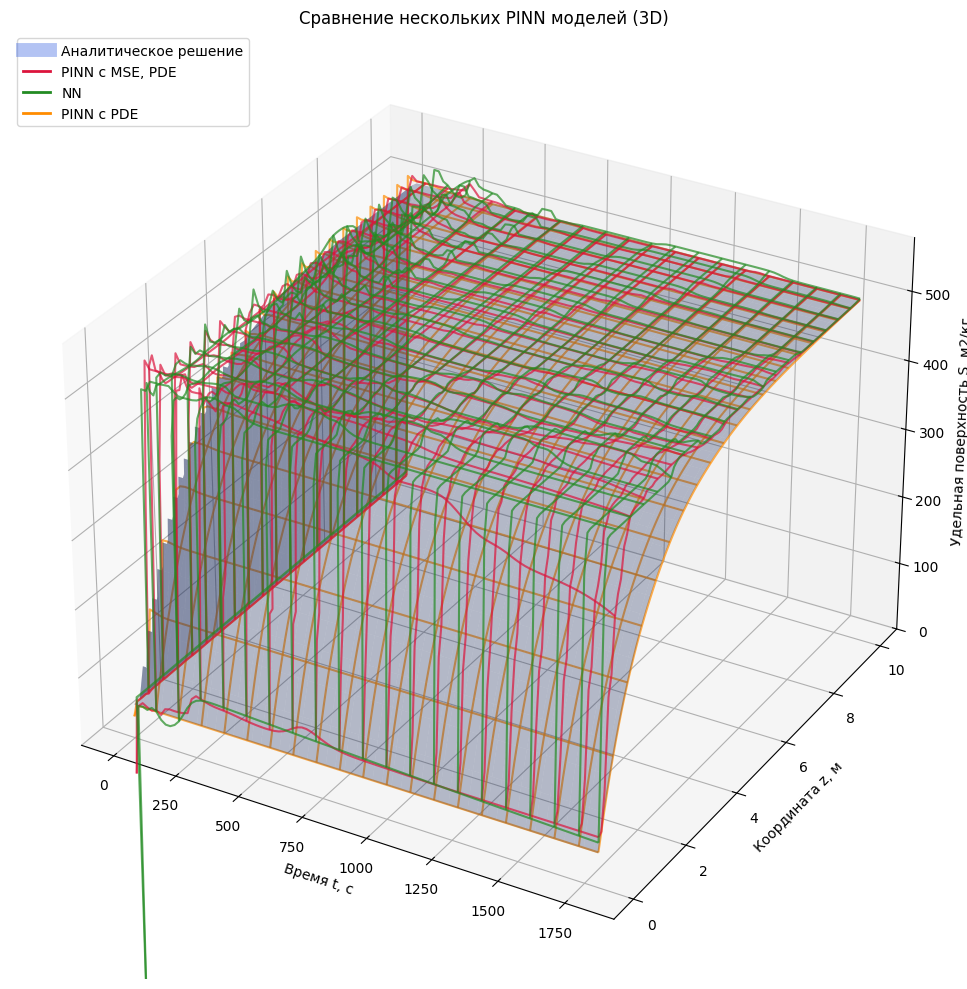

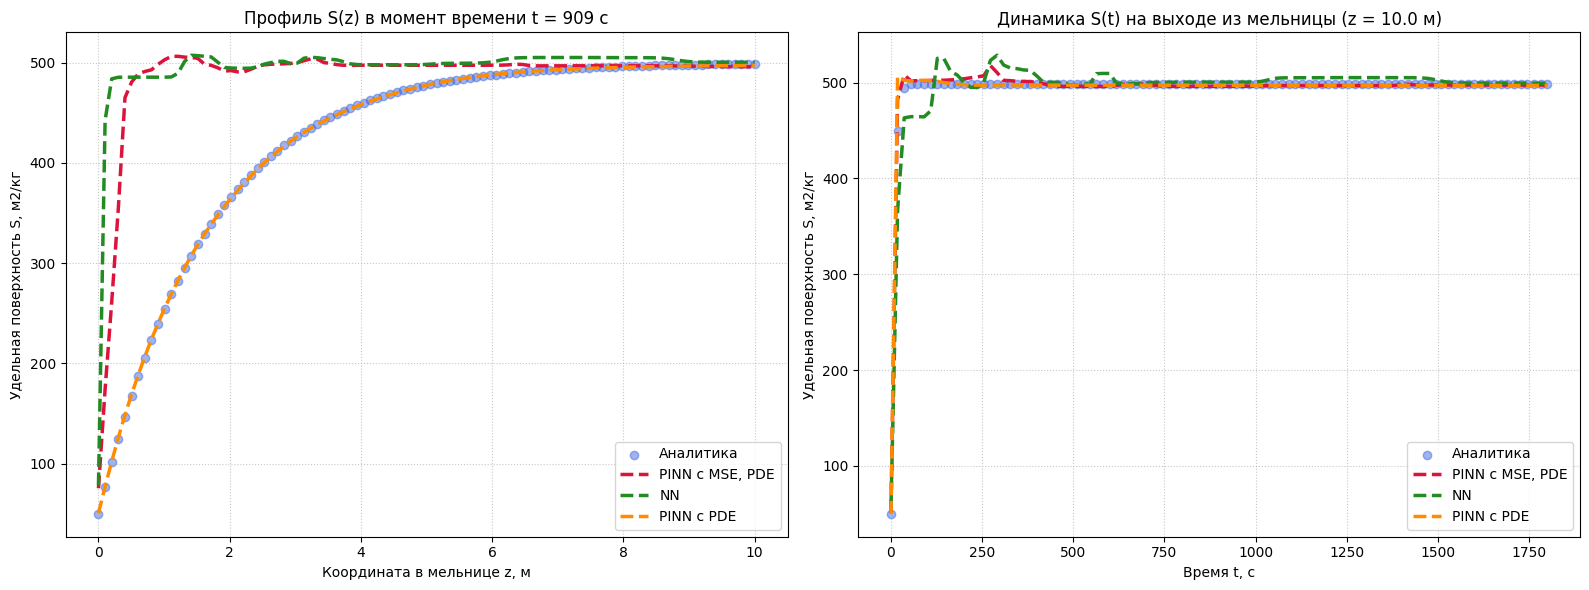

In [54]:
my_models = {
    "PINN с MSE, PDE": pinn_mse_pde,
    "NN": pinn_mse,
    "PINN с PDE": pinn_pde
}

# Строим графики
plot_multiple_pinns(my_models)

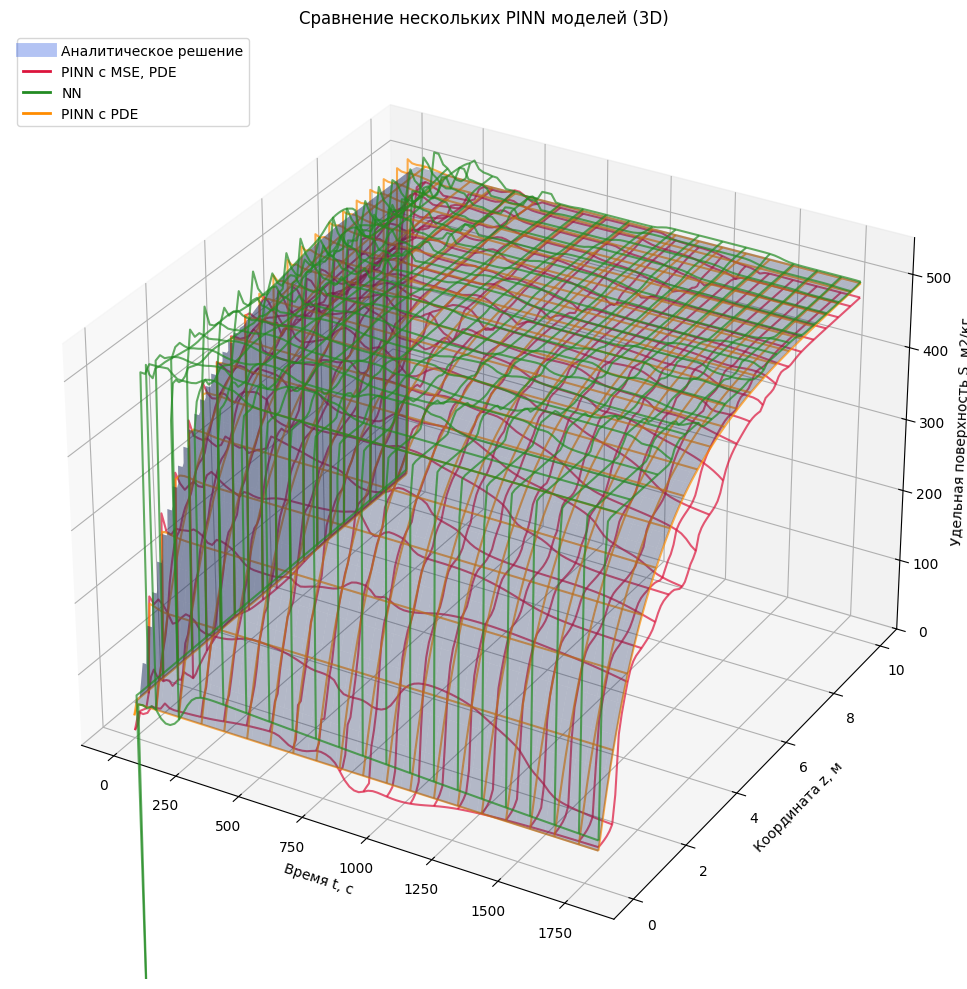

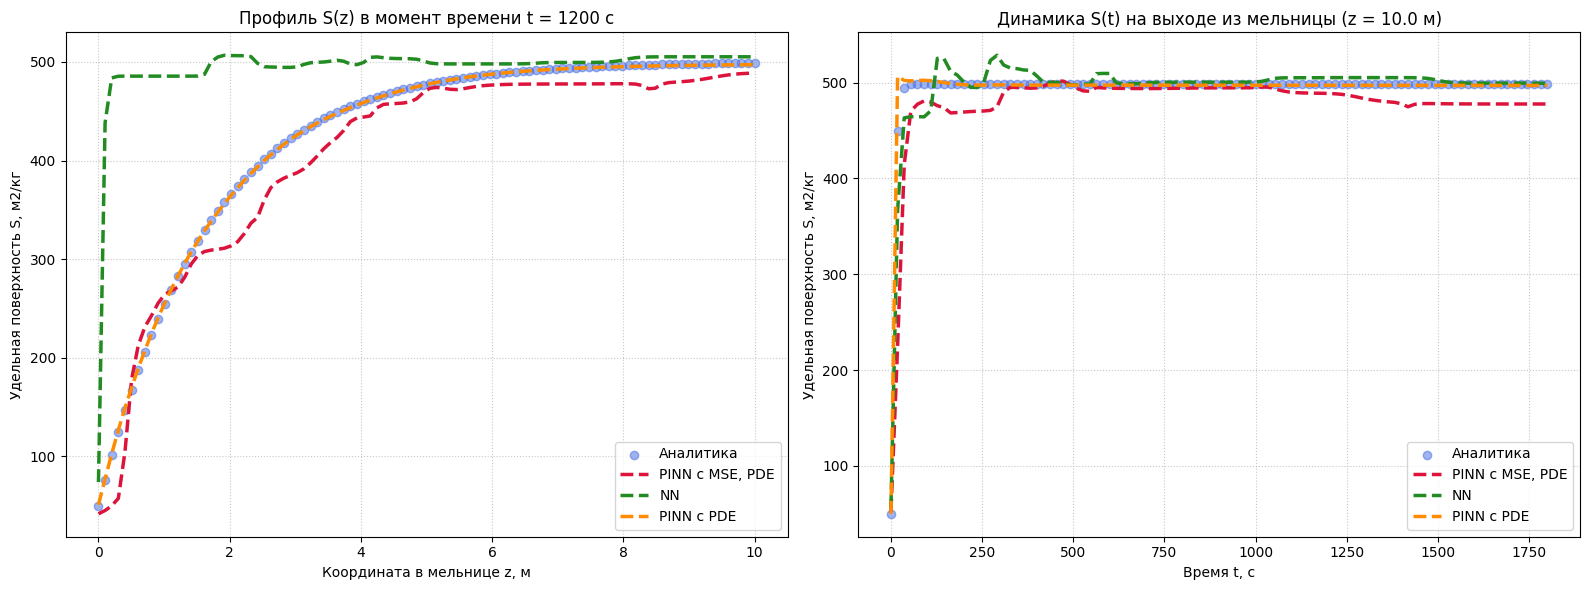

In [ ]:
my_models = {
    "PINN с MSE, PDE": pinn_mse_pde,
    "NN": pinn_mse,
    "PINN с PDE": pinn_pde
}

# Строим графики
plot_multiple_pinns(my_models)

In [200]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=3.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=4.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 525767.438
Epoch 100 | Loss: 483639.594
Epoch 200 | Loss: 455922.219
Epoch 300 | Loss: 430683.500
Epoch 400 | Loss: 407361.594
Epoch 500 | Loss: 385737.219
Epoch 600 | Loss: 365668.750
Epoch 700 | Loss: 346949.719
Epoch 800 | Loss: 328552.500
Epoch 900 | Loss: 311549.312
Epoch 1000 | Loss: 295616.188
Epoch 1100 | Loss: 280706.969
Epoch 1200 | Loss: 266777.344
Epoch 1300 | Loss: 253782.406
Epoch 1400 | Loss: 234616.469
Epoch 1500 | Loss: 219437.219
Epoch 1600 | Loss: 205671.922
Epoch 1700 | Loss: 192694.000
Epoch 1800 | Loss: 180390.078
Epoch 1900 | Loss: 168710.438
Epoch 2000 | Loss: 157673.500
Epoch 2100 | Loss: 147197.641
Epoch 2200 | Loss: 137324.328
Epoch 2300 | Loss: 128224.344
Epoch 2400 | Loss: 119308.891
Epoch 2500 | Loss: 110915.219
Epoch 2600 | Loss: 102982.062
Epoch 2700 | Loss: 95532.789
Epoch 2800 | Loss: 88520.188
Epoch 2900 | Loss: 81923.180
Epoch 3000 | Loss: 75736.289
Epoch 3100 | Loss: 69919.875
Epoch 3200 | Loss: 64461.551
Epoch 3

In [215]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse_pde.pth'))

In [212]:
S_preddd = pinn_mse.predict(data['t_test'], data['z_test']) 
S_preddd - S_test

tensor([[ -50.1896,  -50.1896,  -50.1896,  ...,  -50.1896,  -50.1896,
          -50.1896],
        [ -49.5080,  -75.9708, -100.8773,  ..., -448.7317, -448.7317,
         -448.7317],
        [ -49.4998,  -75.9625, -100.8690,  ..., -493.7704, -493.7704,
         -493.7704],
        ...,
        [ -49.4992,  -75.9619, -100.8685,  ..., -498.2400, -498.3141,
         -498.3837],
        [ -49.4992,  -75.9619, -100.8685,  ..., -498.2400, -498.3141,
         -498.3837],
        [ -49.4992,  -75.9619, -100.8685,  ..., -498.2400, -498.3141,
         -498.3837]])

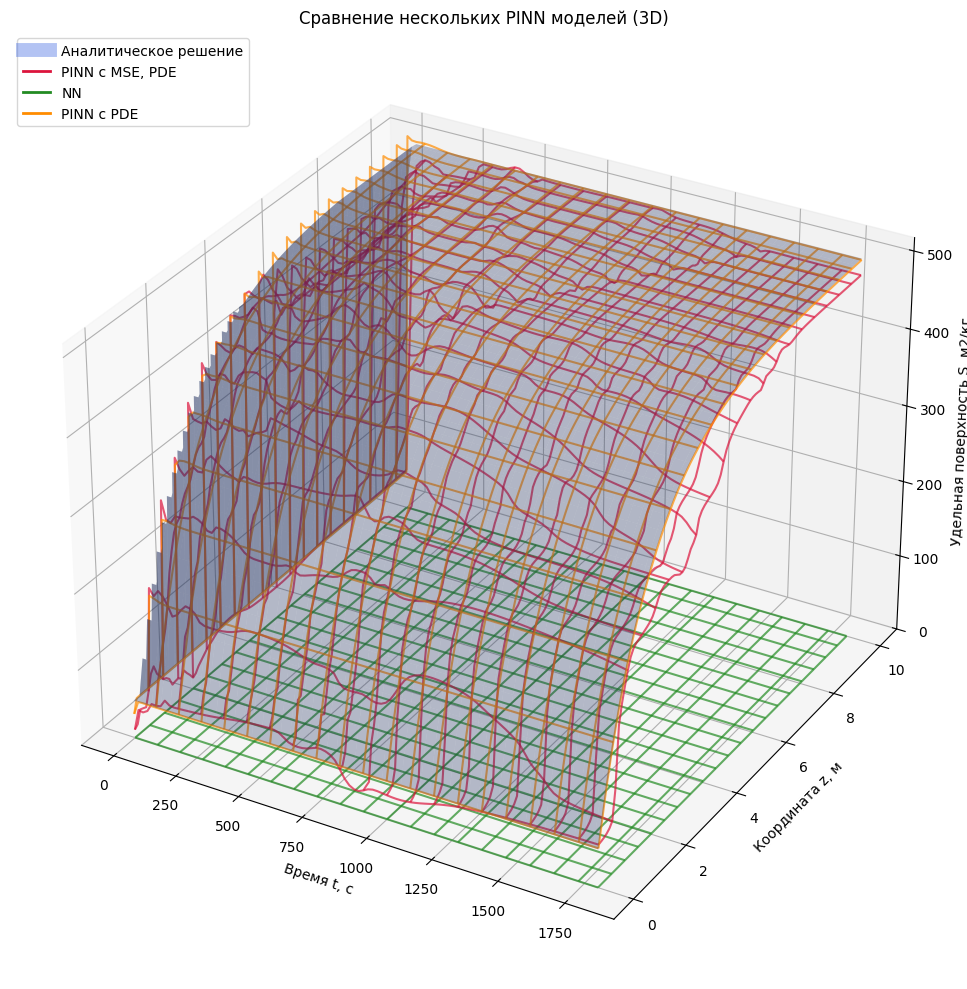

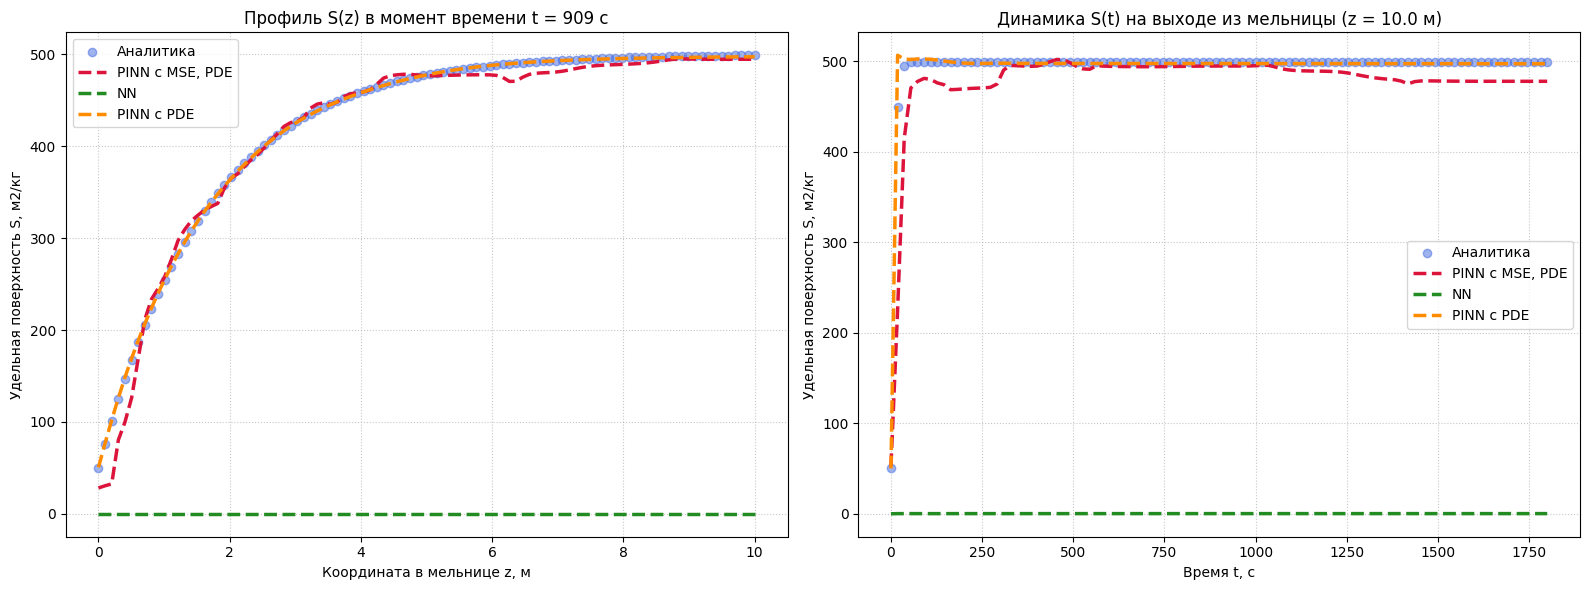

In [214]:
my_models = {
    "PINN с MSE, PDE": pinn,
    "NN": pinn_mse,
    "PINN с PDE": pinn_pde
}

# Строим графики
plot_multiple_pinns(my_models)

## PINN с MSE и обучаемыми параметрами

Обучение PINN с MSE и обучаемыми параметрами k (k_real = 0.12), v_m (v_m_real = 0.2)

In [4]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []
parametr_k = []
list_v = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(40_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_train"], data["z_train"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=2.,
        lambda_bc=20.,
        lambda_ic=20.,
        lambda_mse=30,
    )
    # if epoch != 40_000:
    #     loss.backward(retain_graph=True)
    # else:
    #     loss.backward()
    loss.backward()
    optimizer.step()

    history.append(loss.item())
    parametr_k.append(pinn.k.item())
    list_v.append(pinn.v_m.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k: {pinn.k.item():.3f} | v_m: {pinn.v_m.item():.3f}") 
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 5299948.000 | k: 0.999 | v_m: 0.501
Epoch 100 | Loss: 4825217.500 | k: 0.900 | v_m: 0.534
Epoch 200 | Loss: 4502593.000 | k: 0.802 | v_m: 0.566
Epoch 300 | Loss: 4215770.000 | k: 0.706 | v_m: 0.588
Epoch 400 | Loss: 3957293.500 | k: 0.611 | v_m: 0.605
Epoch 500 | Loss: 3724055.500 | k: 0.519 | v_m: 0.618
Epoch 600 | Loss: 3513875.750 | k: 0.430 | v_m: 0.631
Epoch 700 | Loss: 3324122.500 | k: 0.342 | v_m: 0.644
Epoch 800 | Loss: 3136263.000 | k: 0.258 | v_m: 0.654
Epoch 900 | Loss: 2968159.750 | k: 0.177 | v_m: 0.660
Epoch 1000 | Loss: 2814634.750 | k: 0.098 | v_m: 0.720
Epoch 1100 | Loss: 2609660.750 | k: 0.023 | v_m: 1.221
Epoch 1200 | Loss: 2432115.500 | k: -0.048 | v_m: 1.538
Epoch 1300 | Loss: 2283143.750 | k: -0.115 | v_m: 1.715
Epoch 1400 | Loss: 2136474.750 | k: -0.177 | v_m: 1.843
Epoch 1500 | Loss: 2002513.625 | k: -0.236 | v_m: 1.944
Epoch 1600 | Loss: 1877871.250 | k: -0.292 | v_m: 2.012
Epoch 1700 | Loss: 1760721.875 | k: -0.344 | v_m: 2

KeyboardInterrupt: 

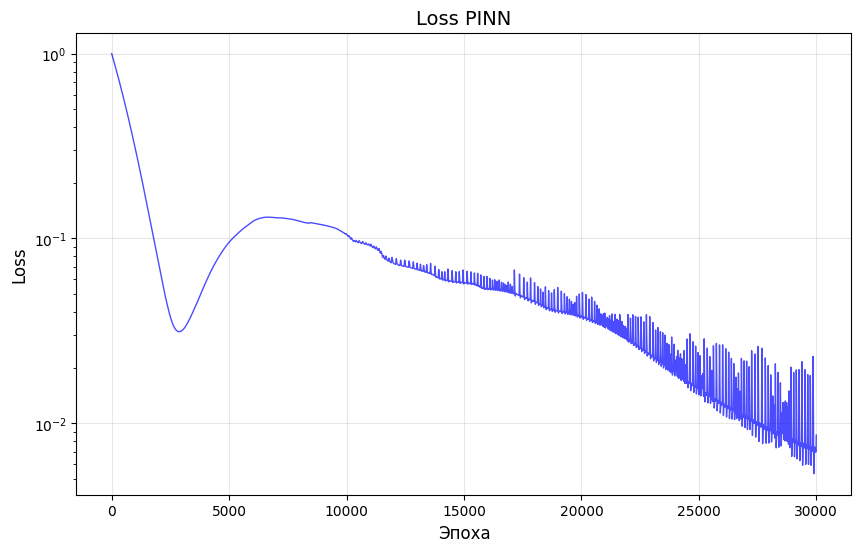

In [11]:
import matplotlib.pyplot as plt

def plot_loss(history):
    """
    Построение графика функции потерь
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history, linewidth=1, color='blue', alpha=0.7)
    plt.xlabel('Эпоха', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss PINN', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.yscale('log') 
    # plt.tight_layout()
    plt.show()

# Вызов после обучения
plot_loss(parametr_k)

## PINN c одним обучаемым параметром S_max

**pinn_Smax.pth** - pinn, обученная простым способо<br>
**pinn_Smax_seq2seq.pth** - pinn с применением sequence to sequence

Smax_data = 500

In [11]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=1e-3)

history = []
parametr_Smax = []
# list_v = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(60_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_pde"], data["z_pde"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=4.,
        lambda_bc=3.,
        lambda_ic=3.,
        lambda_mse=2.,
    )
    loss.backward()
    optimizer.step()

    history.append(loss.item())
    parametr_Smax.append(pinn.S_max.item())
    # list_v.append(pinn.v_m.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | Smax: {pinn.S_max.item():.3f}") 
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 557101.625 | Smax: 99.999
Epoch 100 | Loss: 503971.031 | Smax: 99.902
Epoch 200 | Loss: 470148.750 | Smax: 99.810
Epoch 300 | Loss: 439551.250 | Smax: 99.725
Epoch 400 | Loss: 411472.531 | Smax: 99.647
Epoch 500 | Loss: 385626.312 | Smax: 99.576
Epoch 600 | Loss: 361831.000 | Smax: 99.514
Epoch 700 | Loss: 339945.062 | Smax: 99.461
Epoch 800 | Loss: 319834.688 | Smax: 99.419
Epoch 900 | Loss: 295956.594 | Smax: 99.390
Epoch 1000 | Loss: 275254.969 | Smax: 99.376
Epoch 1100 | Loss: 255680.234 | Smax: 99.381
Epoch 1200 | Loss: 237183.156 | Smax: 99.407
Epoch 1300 | Loss: 219719.500 | Smax: 99.456
Epoch 1400 | Loss: 203248.688 | Smax: 99.528
Epoch 1500 | Loss: 187732.188 | Smax: 99.623
Epoch 1600 | Loss: 173133.438 | Smax: 99.738
Epoch 1700 | Loss: 159418.297 | Smax: 99.868
Epoch 1800 | Loss: 146550.969 | Smax: 100.010
Epoch 1900 | Loss: 134499.969 | Smax: 100.159
Epoch 2000 | Loss: 123233.648 | Smax: 100.312
Epoch 2100 | Loss: 112721.062 | Smax: 100.4

In [27]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_Smax.pth'))

Text(0, 0.5, 'S_test')

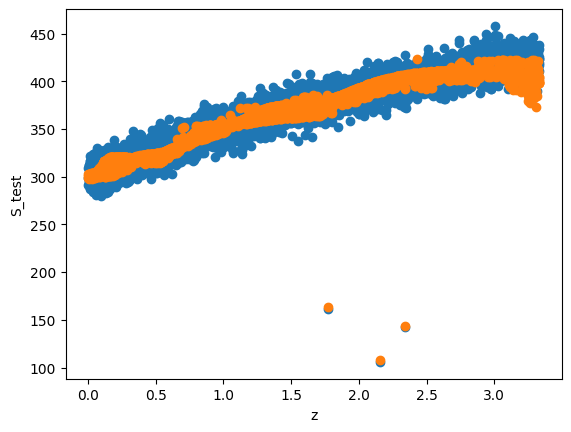

In [13]:
plt.scatter(data["z_train"], data["S_train"])
plt.scatter(data["z_train"], pinn.predict(data["t_train"], data["z_train"]))
plt.xlabel('z')
plt.ylabel('S')

Text(0, 0.5, 'S')

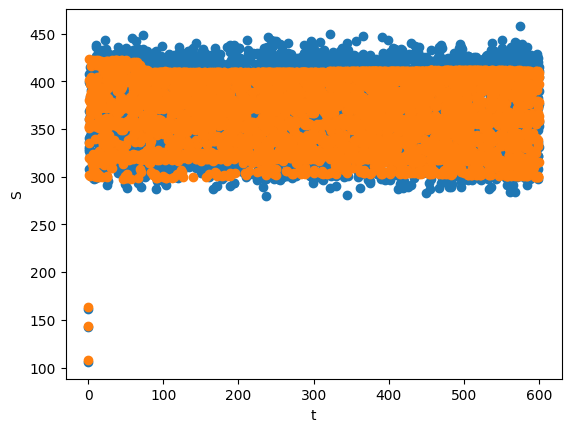

In [16]:
plt.scatter(data["t_train"], data["S_train"])
plt.scatter(data["t_train"], pinn.predict(data["t_train"], data["z_train"]))
plt.xlabel('t')
plt.ylabel('S')

In [17]:
pinn.S_max

Parameter containing:
tensor(150.8926, requires_grad=True)

Text(0.5, 1.0, 'Test')

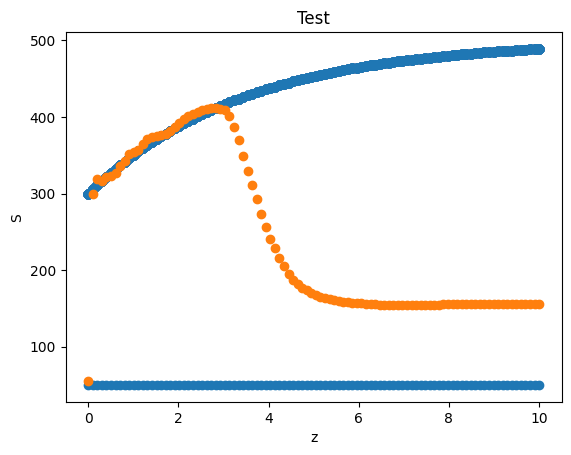

In [64]:
plt.scatter(data["Z"], data["S"])
plt.scatter(data["z_test"], pinn.predict(data["t_test"], data["z_test"]))
plt.xlabel('z')
plt.ylabel('S')
plt.title('Test')

Text(0.5, 1.0, 'Test')

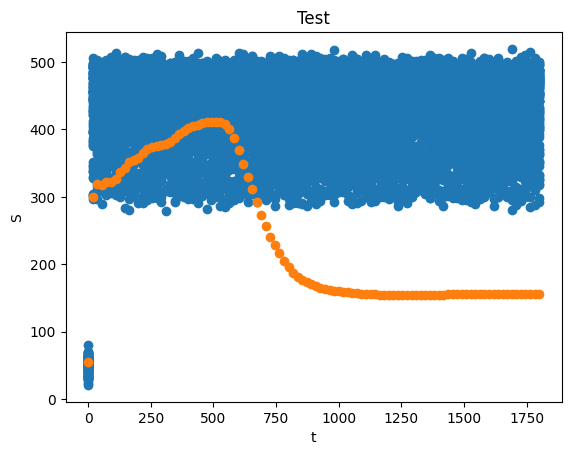

In [62]:
plt.scatter(data["T"], data["S_test"])
plt.scatter(data["t_test"], pinn.predict(data["t_test"], data["z_test"]))
plt.xlabel('t')
plt.ylabel('S')
plt.title('Test')

In [48]:
data['S_test']-pinn.predict(data['t_test'], data['z_test'])

tensor([[-15.6332, -18.6957,   5.3986,  ..., -11.2754,   0.9991,  -8.8466],
        [  5.0310,   2.7208,  -2.4189,  ..., 199.1967, 195.0830, 196.9504],
        [-23.0163, -11.0586,  -8.9425,  ..., 166.9337, 147.4162, 176.5096],
        ...,
        [129.5160, 144.4316, 160.7785,  ..., 342.5797, 329.1417, 338.8918],
        [131.7390, 154.8976, 160.1422,  ..., 330.6857, 322.0215, 326.9117],
        [143.0491, 137.1835, 162.1430,  ..., 321.0344, 330.5196, 319.2195]])

Text(0.5, 1.0, 'MAE')

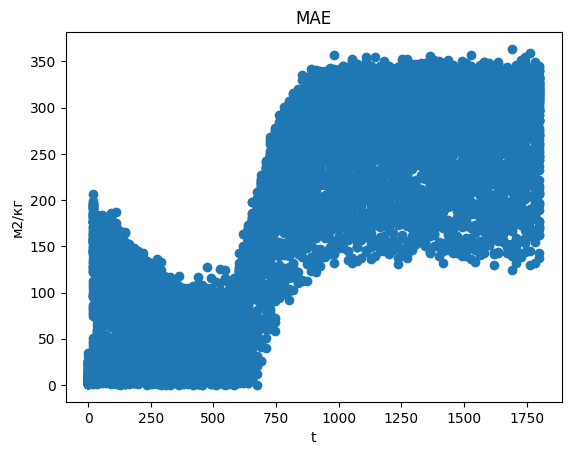

In [68]:
plt.scatter(data['T'], torch.abs(data['S_test']- pinn.predict(data['t_test'], data['z_test'])))
plt.xlabel('t')
plt.ylabel('м2/кг')
plt.title('MAE')

# Обучение с seq2seq

In [21]:
pinn = PINN()

history = []
parametr_Smax = []

T_final = data["t_train"].max().item()
Z_final = data["z_train"].max().item()

n_t = 5
n_z = 5

dt = T_final / n_t
dz = Z_final / n_z

print("START 2D SEQ2SEQ TRAINING")


def select_block(t, z, *others, t0, t1, z0, z1):
    mask = (
        (t >= t0) & (t <= t1) &
        (z >= z0) & (z <= z1)
    )

    result = [t[mask], z[mask]]

    for item in others:
        result.append(item[mask])

    return result


for i in range(n_t):
    for j in range(n_z):

        t0, t1 = i * dt, (i + 1) * dt
        z0, z1 = j * dz, (j + 1) * dz

        print(f"\nBLOCK t:[{t0:.3f},{t1:.3f}] z:[{z0:.3f},{z1:.3f}]")

        # ==================================================
        # DATA INSIDE CURRENT BLOCK
        # ==================================================
        t_pde, z_pde = select_block(
            data["t_pde"],
            data["z_pde"],
            t0=t0, t1=t1, z0=z0, z1=z1
        )

        t_bc, z_bc, S_bc = select_block(
            data["t_bc"],
            data["z_bc"],
            data["S_bc"],
            t0=t0, t1=t1, z0=z0, z1=z1
        )

        t_real, z_real, S_real = select_block(
            data["t_train"],
            data["z_train"],
            data["S_train"],
            t0=t0, t1=t1, z0=z0, z1=z1
        )

        # если блок пустой — пропускаем
        if len(t_pde) == 0:
            print("Empty PDE block -> skip")
            continue

        # ==================================================
        # INITIAL CONDITION (FROM PREVIOUS TIME BLOCK)
        # ==================================================
        if i == 0:
            t_ic, z_ic, S_ic = select_block(
                data["t_ic"],
                data["z_ic"],
                data["S_ic"],
                t0=t0, t1=t1, z0=z0, z1=z1
            )
        else:
            with torch.no_grad():
                z_ic = torch.linspace(
                    z0, z1, 100,
                    device=data["z_train"].device
                ).reshape(-1, 1)

                t_ic = torch.full_like(z_ic, t0)

                S_ic = pinn.predict(t_ic, z_ic)

        # ==================================================
        # LEFT BOUNDARY (FROM PREVIOUS Z BLOCK)
        # ==================================================
        if j > 0:
            with torch.no_grad():
                t_left = torch.linspace(
                    t0, t1, 100,
                    device=data["t_train"].device
                ).reshape(-1, 1)

                z_left = torch.full_like(t_left, z0)

                S_left = pinn.predict(t_left, z_left)

            t_bc = torch.cat([t_bc, t_left], dim=0)
            z_bc = torch.cat([z_bc, z_left], dim=0)
            S_bc = torch.cat([S_bc, S_left], dim=0)

        # ==================================================
        # TRAIN CURRENT BLOCK
        # ==================================================
        optimizer = optim.Adam(pinn.parameters(), lr=1e-3)

        for epoch in range(10_000):
            pinn.train()
            optimizer.zero_grad()

            loss = pinn_loss(
                pinn,
                t_pde, z_pde,
                t_bc, z_bc, S_bc,
                t_ic, z_ic, S_ic,
                t_real=t_real,
                z_real=z_real,
                S_real=S_real,
                lambda_pde=8.,
                lambda_bc=1.,
                lambda_ic=1.,
                lambda_mse=5.,
            )

            loss.backward()
            optimizer.step()

            history.append(loss.item())
            parametr_Smax.append(pinn.S_max.item())

            if epoch % 500 == 0:
                print(
                    f"Block ({i},{j}) "
                    f"Epoch {epoch} | "
                    f"Loss {loss.item():.6f} | "
                    f"Smax {pinn.S_max.item():.3f}"
                )

START 2D SEQ2SEQ TRAINING

BLOCK t:[0.000,119.975] z:[0.000,0.667]
Block (0,0) Epoch 0 | Loss 600856.812500 | Smax 99.999


/Users/anna/Desktop/uni/PINN/src/loss/pinn_loss.py:20: UserWarning: Using a target size (torch.Size([3])) that is different to the input size (torch.Size([3, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_bc = F.mse_loss(S_pred_bc, S_bc)
/Users/anna/Desktop/uni/PINN/src/loss/pinn_loss.py:24: UserWarning: Using a target size (torch.Size([23])) that is different to the input size (torch.Size([23, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_ic = F.mse_loss(S_pred_ic, S_ic)
/Users/anna/Desktop/uni/PINN/src/loss/pinn_loss.py:28: UserWarning: Using a target size (torch.Size([217])) that is different to the input size (torch.Size([217, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(S_pred, S_real)


Block (0,0) Epoch 500 | Loss 407335.281250 | Smax 99.577
Block (0,0) Epoch 1000 | Loss 280575.843750 | Smax 99.387
Block (0,0) Epoch 1500 | Loss 184254.968750 | Smax 99.647
Block (0,0) Epoch 2000 | Loss 115049.656250 | Smax 100.339
Block (0,0) Epoch 2500 | Loss 67648.898438 | Smax 101.103
Block (0,0) Epoch 3000 | Loss 37393.101562 | Smax 101.825
Block (0,0) Epoch 3500 | Loss 19933.841797 | Smax 102.502
Block (0,0) Epoch 4000 | Loss 11202.787109 | Smax 103.140
Block (0,0) Epoch 4500 | Loss 7629.613770 | Smax 103.746
Block (0,0) Epoch 5000 | Loss 6512.193848 | Smax 104.323
Block (0,0) Epoch 5500 | Loss 6256.351562 | Smax 104.877
Block (0,0) Epoch 6000 | Loss 6241.016602 | Smax 105.412
Block (0,0) Epoch 6500 | Loss 6175.633301 | Smax 105.933
Block (0,0) Epoch 7000 | Loss 6150.593750 | Smax 106.445
Block (0,0) Epoch 7500 | Loss 6126.765625 | Smax 106.951
Block (0,0) Epoch 8000 | Loss 6103.123047 | Smax 107.455
Block (0,0) Epoch 8500 | Loss 6079.671875 | Smax 107.955
Block (0,0) Epoch 9000 

/Users/anna/Desktop/uni/PINN/src/loss/pinn_loss.py:24: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_ic = F.mse_loss(S_pred_ic, S_ic)
/Users/anna/Desktop/uni/PINN/src/loss/pinn_loss.py:28: UserWarning: Using a target size (torch.Size([205])) that is different to the input size (torch.Size([205, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(S_pred, S_real)


Block (0,1) Epoch 500 | Loss 8330.194336 | Smax 109.968
Block (0,1) Epoch 1000 | Loss 8293.496094 | Smax 110.480
Block (0,1) Epoch 1500 | Loss 8266.955078 | Smax 110.985
Block (0,1) Epoch 2000 | Loss 8240.639648 | Smax 111.486
Block (0,1) Epoch 2500 | Loss 8214.469727 | Smax 111.986
Block (0,1) Epoch 3000 | Loss 8188.354492 | Smax 112.485
Block (0,1) Epoch 3500 | Loss 8162.296875 | Smax 112.985
Block (0,1) Epoch 4000 | Loss 8136.295410 | Smax 113.485
Block (0,1) Epoch 4500 | Loss 8110.349609 | Smax 113.985
Block (0,1) Epoch 5000 | Loss 8084.460938 | Smax 114.484
Block (0,1) Epoch 5500 | Loss 8058.588379 | Smax 114.984
Block (0,1) Epoch 6000 | Loss 4067.021240 | Smax 115.308
Block (0,1) Epoch 6500 | Loss 2767.815430 | Smax 115.725
Block (0,1) Epoch 7000 | Loss 1518.848511 | Smax 115.790
Block (0,1) Epoch 7500 | Loss 1547.557983 | Smax 115.843
Block (0,1) Epoch 8000 | Loss 1345.346802 | Smax 115.865
Block (0,1) Epoch 8500 | Loss 1441.815308 | Smax 115.980
Block (0,1) Epoch 9000 | Loss 12

...

Block (4,0) Epoch 500 | Loss 9042.293945 | Smax 265.440
Block (4,0) Epoch 1000 | Loss 9036.000000 | Smax 265.899
Block (4,0) Epoch 1500 | Loss 9030.163086 | Smax 266.377
Block (4,0) Epoch 2000 | Loss 9022.933594 | Smax 266.865
Block (4,0) Epoch 2500 | Loss 9016.406250 | Smax 267.353
Block (4,0) Epoch 3000 | Loss 9009.931641 | Smax 267.841
Block (4,0) Epoch 3500 | Loss 9003.511719 | Smax 268.330
Block (4,0) Epoch 4000 | Loss 8997.146484 | Smax 268.818
Block (4,0) Epoch 4500 | Loss 8990.833984 | Smax 269.306
Block (4,0) Epoch 5000 | Loss 8984.577148 | Smax 269.795
Block (4,0) Epoch 5500 | Loss 8978.374023 | Smax 270.283
Block (4,0) Epoch 6000 | Loss 8972.223633 | Smax 270.771
Block (4,0) Epoch 6500 | Loss 8966.128906 | Smax 271.259
Block (4,0) Epoch 7000 | Loss 8960.153320 | Smax 271.748
Block (4,0) Epoch 7500 | Loss 8954.101562 | Smax 272.236
Block (4,0) Epoch 8000 | Loss 8948.166992 | Smax 272.724
Block (4,0) Epoch 8500 | Loss 8942.286133 | Smax 273.213
Block (4,0) Epoch 9000 | Loss 89

/Users/anna/Desktop/uni/PINN/src/loss/pinn_loss.py:28: UserWarning: Using a target size (torch.Size([213])) that is different to the input size (torch.Size([213, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(S_pred, S_real)


Block (4,1) Epoch 500 | Loss 2283.643555 | Smax 275.182
Block (4,1) Epoch 1000 | Loss 2275.897217 | Smax 275.685
Block (4,1) Epoch 1500 | Loss 2268.208496 | Smax 276.189
Block (4,1) Epoch 2000 | Loss 2260.791504 | Smax 276.678
Block (4,1) Epoch 2500 | Loss 2253.444824 | Smax 277.166
Block (4,1) Epoch 3000 | Loss 2246.151855 | Smax 277.655
Block (4,1) Epoch 3500 | Loss 2238.913086 | Smax 278.143
Block (4,1) Epoch 4000 | Loss 2231.728516 | Smax 278.631
Block (4,1) Epoch 4500 | Loss 2224.597656 | Smax 279.120
Block (4,1) Epoch 5000 | Loss 2217.520996 | Smax 279.608
Block (4,1) Epoch 5500 | Loss 2210.498535 | Smax 280.096
Block (4,1) Epoch 6000 | Loss 2203.529785 | Smax 280.584
Block (4,1) Epoch 6500 | Loss 2196.615234 | Smax 281.073
Block (4,1) Epoch 7000 | Loss 2189.754639 | Smax 281.561
Block (4,1) Epoch 7500 | Loss 2182.948242 | Smax 282.049
Block (4,1) Epoch 8000 | Loss 2176.195801 | Smax 282.538
Block (4,1) Epoch 8500 | Loss 2169.497559 | Smax 283.026
Block (4,1) Epoch 9000 | Loss 21

/Users/anna/Desktop/uni/PINN/src/loss/pinn_loss.py:28: UserWarning: Using a target size (torch.Size([222])) that is different to the input size (torch.Size([222, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(S_pred, S_real)


Block (4,4) Epoch 500 | Loss 2948.552979 | Smax 304.675
Block (4,4) Epoch 1000 | Loss 2936.678223 | Smax 305.178
Block (4,4) Epoch 1500 | Loss 2924.861084 | Smax 305.682
Block (4,4) Epoch 2000 | Loss 2913.101074 | Smax 306.186
Block (4,4) Epoch 2500 | Loss 2901.398682 | Smax 306.689
Block (4,4) Epoch 3000 | Loss 2889.753662 | Smax 307.193
Block (4,4) Epoch 3500 | Loss 2878.475098 | Smax 307.683
Block (4,4) Epoch 4000 | Loss 2867.292480 | Smax 308.171
Block (4,4) Epoch 4500 | Loss 2856.163330 | Smax 308.659
Block (4,4) Epoch 5000 | Loss 2845.088623 | Smax 309.147
Block (4,4) Epoch 5500 | Loss 2834.067383 | Smax 309.636
Block (4,4) Epoch 6000 | Loss 2823.101074 | Smax 310.124
Block (4,4) Epoch 6500 | Loss 2812.187988 | Smax 310.612
Block (4,4) Epoch 7000 | Loss 2801.329590 | Smax 311.101
Block (4,4) Epoch 7500 | Loss 2790.524902 | Smax 311.589
Block (4,4) Epoch 8000 | Loss 2779.774414 | Smax 312.077
Block (4,4) Epoch 8500 | Loss 2769.077637 | Smax 312.565
Block (4,4) Epoch 9000 | Loss 27

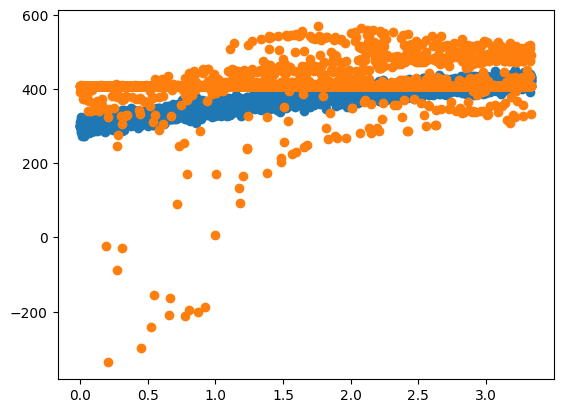

In [22]:
plt.scatter(data["z_train"], data["S_train"])
plt.scatter(data["z_train"], pinn.predict(data["t_train"], data["z_train"]))

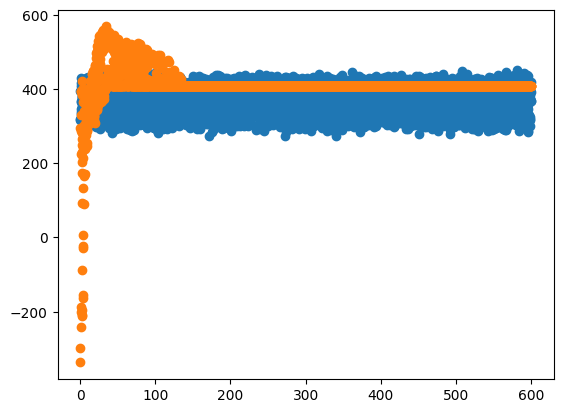

In [23]:
plt.scatter(data["t_train"], data["S_train"])
plt.scatter(data["t_train"], pinn.predict(data["t_train"], data["z_train"]))

In [24]:
pinn.S_max

Parameter containing:
tensor(314.0293, requires_grad=True)

In [25]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_Smax_seq2seq.pth'))

In [37]:
pinn_smax = PINN()

checkpoint = torch.load('/Users/anna/Desktop/uni/PINN/src/models/pinn_Smax.pth')
pinn_smax.load_state_dict(checkpoint["model_state_dict"])

pinn_smax.eval()

pinn_seq = PINN()

checkpoint = torch.load('/Users/anna/Desktop/uni/PINN/src/models/pinn_Smax_seq2seq.pth')
pinn_seq.load_state_dict(checkpoint["model_state_dict"])

pinn_seq.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): Tanh()
    (6): Linear(in_features=100, out_features=1, bias=True)
  )
)

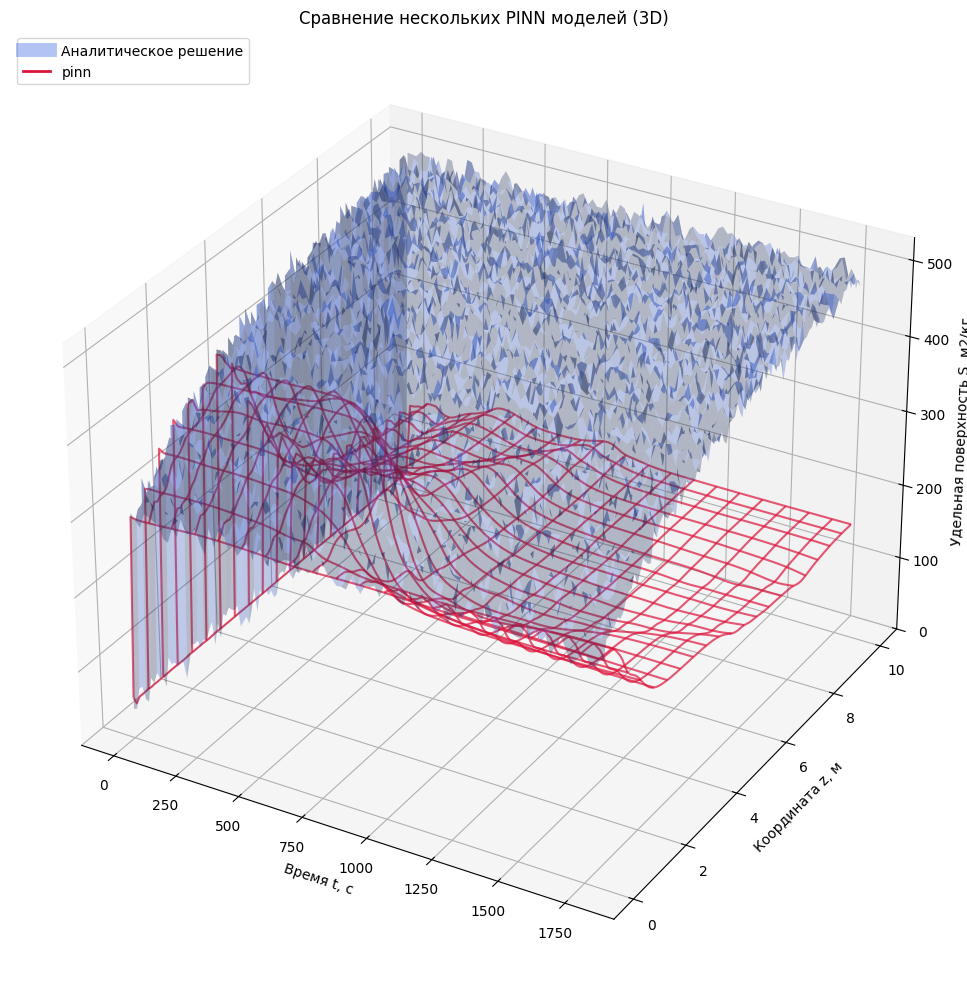

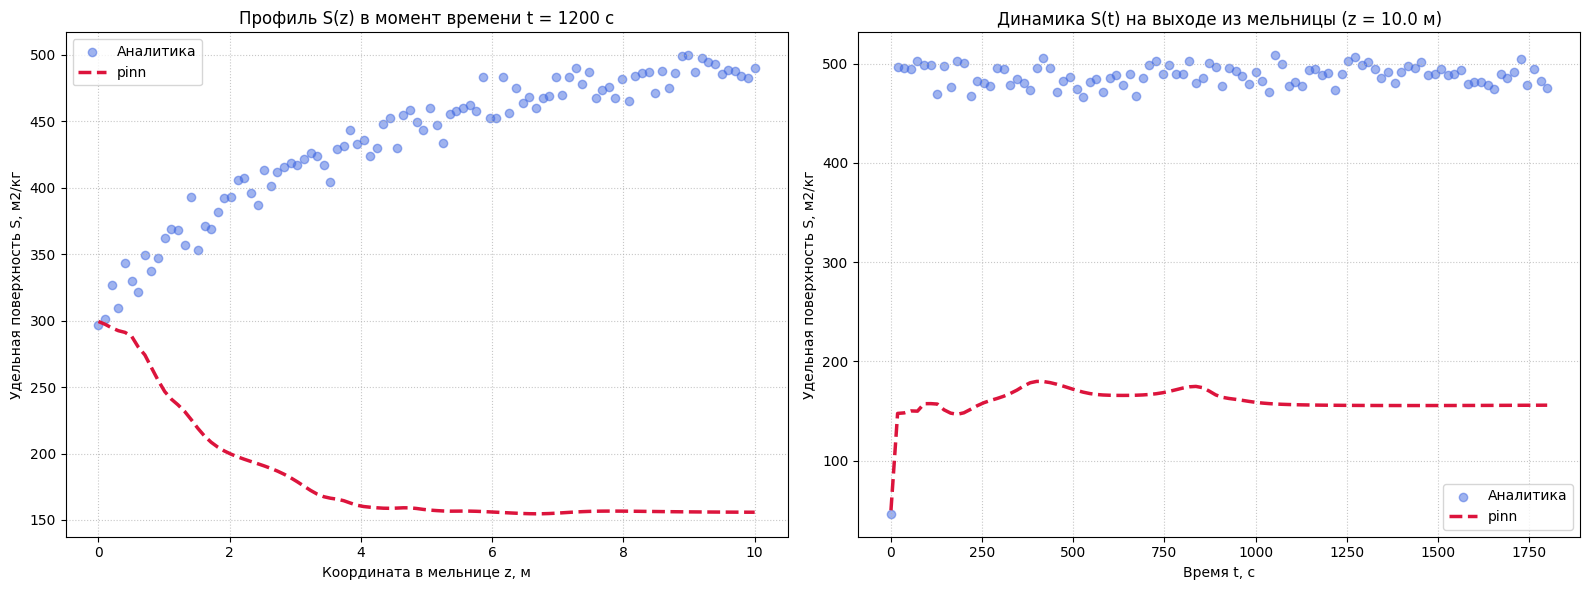

In [22]:
plot_multiple_pinns({"pinn": pinn})

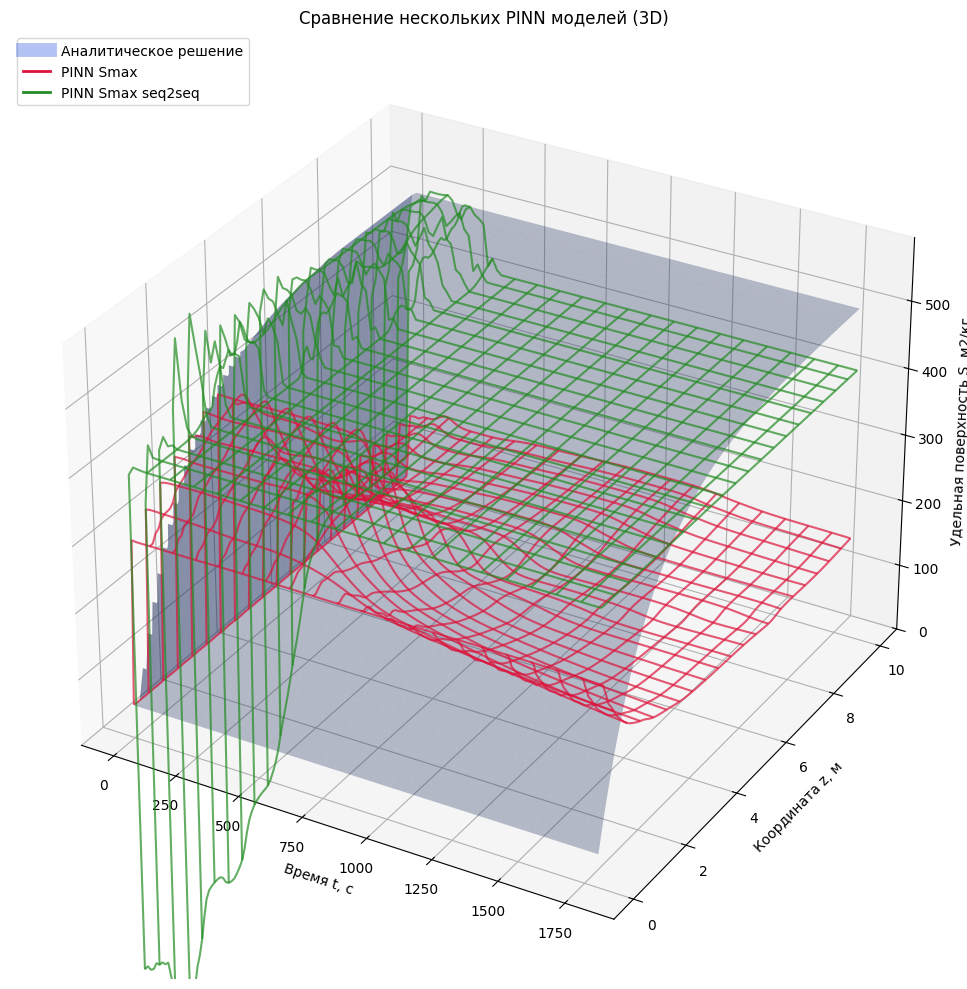

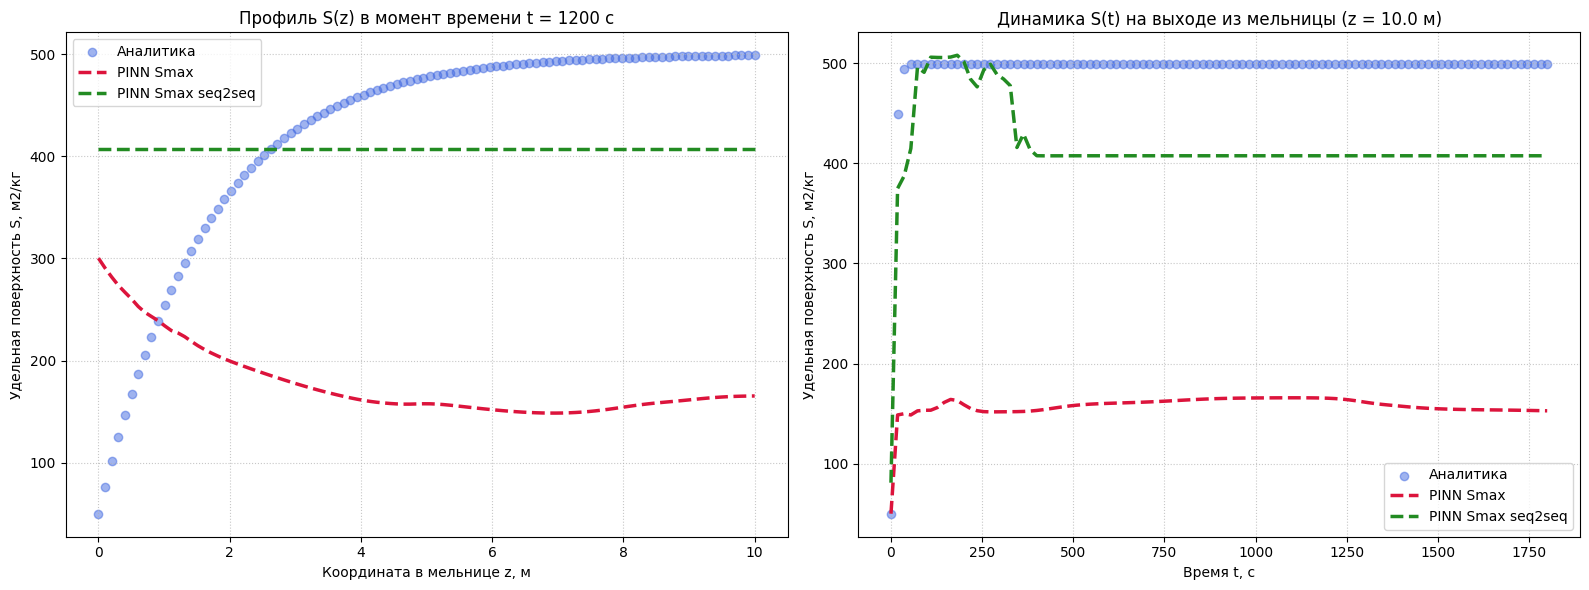

In [38]:
my_models = {
    "PINN Smax": pinn_smax,
    "PINN Smax seq2seq": pinn_seq,
}

# Строим графики
plot_multiple_pinns(my_models)

# PINN на промышленных данных

In [71]:
Fm = 60 / 3.6
L_max_ind = 4.5
M = 7000 / L_max_ind
vm_ind = Fm / M


print('vm =', vm_ind, '\nFm =', Fm, '\nM =', M)

vm = 0.010714285714285714 
Fm = 16.666666666666668 
M = 1555.5555555555557


In [4]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(2_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    # t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=3.,
                    lambda_bc=1.,
                    lambda_ic=1.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 9.245
Epoch 100 | Loss: 0.433
Epoch 200 | Loss: 0.248
Epoch 300 | Loss: 0.190
Epoch 400 | Loss: 0.160
Epoch 500 | Loss: 0.506
Epoch 600 | Loss: 0.419
Epoch 700 | Loss: 0.064
Epoch 800 | Loss: 0.075
Epoch 900 | Loss: 0.147
Epoch 1000 | Loss: 0.054
Epoch 1100 | Loss: 0.033
Epoch 1200 | Loss: 0.062
Epoch 1300 | Loss: 0.026
Epoch 1400 | Loss: 0.089
Epoch 1500 | Loss: 0.022
Epoch 1600 | Loss: 0.060
Epoch 1700 | Loss: 0.015
Epoch 1800 | Loss: 0.051
Epoch 1900 | Loss: 0.010


In [5]:
t = torch.linspace(0, 408, 20)
z = torch.linspace(0, 4.5, 20)

In [9]:
pinn.predict(t, z)[-1]

tensor([5.1926])

In [7]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_pde_industrial.pth'))

In [29]:
y_true = np.array([5.2465])
y_pred = pinn.predict(t, z)[-1]


metrics = {
    "MSE": mean_squared_error(y_true, y_pred),
    "MAE": mean_absolute_error(y_true, y_pred),
}


In [30]:
metrics

{'MSE': 0.002906725312590675, 'MAE': 0.05391405487060563}

In [31]:
print(f"\n{'= ' * 13}")
print(f"| {'Метрика':<10} | {'Значение':<11} |")
print(f"{'= ' * 13}")
for key, value in metrics.items():
    # Выводит NaN как строку, а числа форматирует до 6 знаков
    val_str = f"{value:.6f}" if isinstance(value, (int, float)) and not np.isnan(value) else str(value)
    print(f"| {key:<10} | {val_str:<11} |")
print(f"{'= ' * 13}\n")


= = = = = = = = = = = = = 
| Метрика    | Значение    |
= = = = = = = = = = = = = 
| MSE        | 0.002907    |
| MAE        | 0.053914    |
= = = = = = = = = = = = = 



# MDN с одним распределением

In [4]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.MDN import MDN
from loss.mdn_loss import mdn_loss

In [5]:
pinn = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse_pde.pth"))
pinn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

pinn.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [6]:
# --- train ---
t_train = data['t_train']
z_train = data['z_train']
S_train = data['S_train']
# --- test ---
t_test = data['t_test']
z_test = data['z_test']
T, Z = torch.meshgrid(t_test, z_test, indexing='ij')
S_test = data['S_test'].reshape(-1, 1)
S = data['S'].reshape(-1, 1)

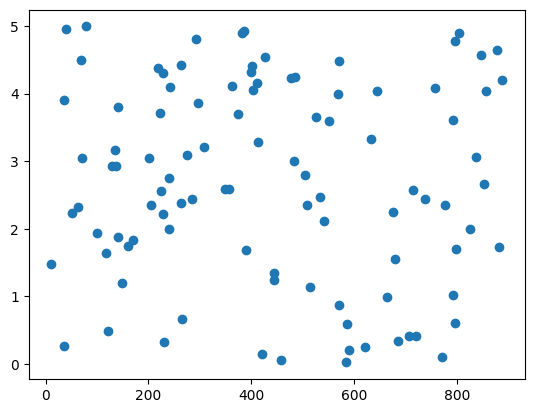

In [10]:
plt.scatter(t_train,z_train)
plt.show()

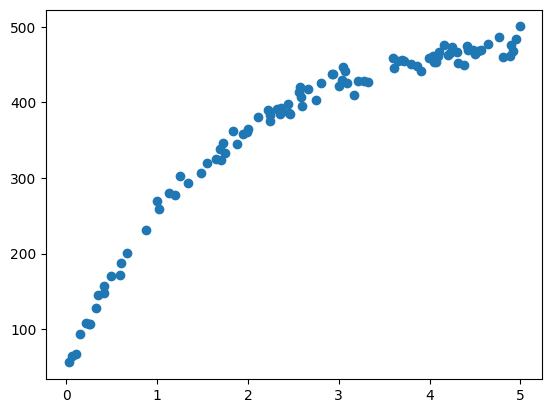

In [22]:
plt.scatter(z_train,S_train)
plt.show()

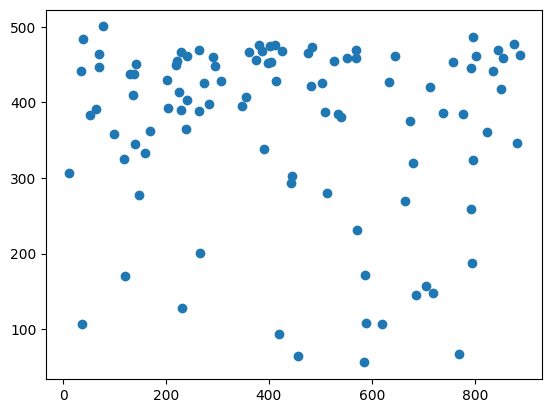

In [23]:
plt.scatter(t_train,S_train)
plt.show()

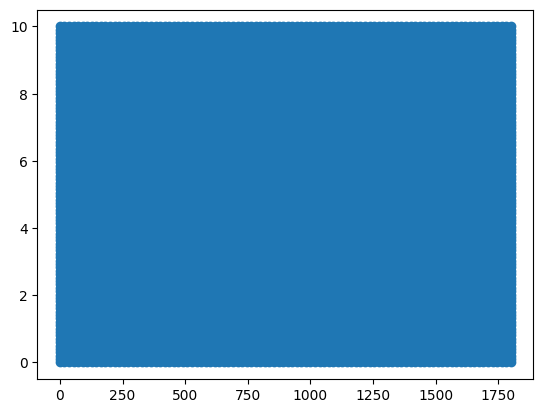

In [11]:
plt.scatter(T,Z)
plt.show()

In [7]:
stacked = torch.stack([T.flatten(), Z.flatten()], dim=1)

T_test, Z_test = stacked[:, 0].reshape(-1, 1), stacked[:, 1].reshape(-1, 1)
print(T_test.shape, Z_test.shape)

torch.Size([10000, 1]) torch.Size([10000, 1])


In [8]:
S_pred_test = pinn.predict(T_test,Z_test)

In [9]:
S_pred_train = pinn.predict(t_train,z_train)

In [10]:
mdn = MDN()
optimizer = torch.optim.Adam(mdn.parameters(), lr=0.001)
epochs = 20_000
mdn_input=torch.cat([t_train, z_train, S_pred_train],dim=1)
residual = S_train-S_pred_train

mdn.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Прямой проход
    mu, sigma = mdn.forward(mdn_input)
    
    # Расчет потерь
    loss = mdn_loss(mu, sigma, residual)
    
    # Обратный проход и шаг
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

Epoch 0/20000, Loss: 306080.6562
Epoch 1000/20000, Loss: 3.2626
Epoch 2000/20000, Loss: 3.2372
Epoch 3000/20000, Loss: 3.2248
Epoch 4000/20000, Loss: 3.2181
Epoch 5000/20000, Loss: 3.2147
Epoch 6000/20000, Loss: 3.2124
Epoch 7000/20000, Loss: 3.2109
Epoch 8000/20000, Loss: 3.2101
Epoch 9000/20000, Loss: 3.2096
Epoch 10000/20000, Loss: 3.2097
Epoch 11000/20000, Loss: 3.2094
Epoch 12000/20000, Loss: 3.2098
Epoch 13000/20000, Loss: 3.2093
Epoch 14000/20000, Loss: 3.2094
Epoch 15000/20000, Loss: 3.2093
Epoch 16000/20000, Loss: 3.2093
Epoch 17000/20000, Loss: 3.2092
Epoch 18000/20000, Loss: 3.2096
Epoch 19000/20000, Loss: 3.2092


In [16]:
print(T.shape, t_train.shape)

torch.Size([100, 100]) torch.Size([100, 1])


In [17]:
print(Z.shape, z_train.shape)

torch.Size([100, 100]) torch.Size([100, 1])


In [36]:
mdn_input=torch.cat([T_test, Z_test, S_pred_test],dim=1)
mean, lower, upper = mdn.predict(mdn_input)
print(mean.shape, lower.shape, upper.shape)
mean, lower, upper = mean.unsqueeze(-1)+S_pred_test, lower.unsqueeze(-1)+S_pred_test, upper.unsqueeze(-1)+S_pred_test

torch.Size([10000]) torch.Size([10000]) torch.Size([10000])


In [35]:
mean.shape

torch.Size([10000, 1])

In [33]:
stacked = torch.stack([mean.flatten(),lower.flatten(), upper.flatten()], dim=1)

mean, lower, upper = stacked[:, 0].reshape(-1, 1), stacked[:, 1].reshape(-1, 1), stacked[:, 2].reshape(-1, 1)
print(mean.shape, lower.shape, upper.shape,)

torch.Size([10000, 1]) torch.Size([10000, 1]) torch.Size([10000, 1])


In [41]:
error = S_pred_test - mean
mse = torch.mean(error**2).item()
mae = torch.mean(torch.abs(error)).item()
rmse = torch.sqrt(torch.mean(error**2)).item()

print(f'--- Метрики среднего значения ---\nMSE: {mse:.2f}, \nMAE: {mae:.2f}, \nRMSE: {rmse:.2f}')

--- Метрики среднего значения ---
MSE: 2.22, 
MAE: 1.23, 
RMSE: 1.49


In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def regression_metrics(model, x, S_pred, S_true):
    model.eval()

    mu, sigma = model(x)
    y_hat = S_pred.squeeze() + mu

    y_true = S_true.squeeze()

    # ошибки
    error = y_true - y_hat

    mse = torch.mean(error**2).item()
    mae = torch.mean(torch.abs(error)).item()
    rmse = torch.sqrt(torch.mean(error**2)).item()

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse
    }